<div align="left">
<img src="logos/foccus.png" alt="FOCCUS" width="120">
<img src="logos/shom.png" alt="Shom" width="200">
<img src="logos/moi.png" alt="Mercator Ocean International" width="120">
</div>

<!-- Logo files expected in ./logos/ :
       foccus.png  — project logo
       shom.png    — application lead
       moi.png     — application co-lead
     Replace paths / add partners as needed. -->

---

# Improving the storm-surge forecast on the French Atlantic coast

**Shom** & **Mercator Ocean International (MOi)** · Bay of Biscay and English Channel


---
# WHY? — Context & objectives

The objective of this demonstrator is to showcase the results of the coastal application *Improving storm-surge forecasts on the Atlantic French coast*, which addresses the Environmental and Societal Challenge of **natural hazards and extreme events** for the French Atlantic coasts pilot area.

Coastal flood warnings issued by the French national weather service, Météo-France, are based on storm surge forecasts generated by **Tolosa-SW**, an unstructured **barotropic** model. Being barotropic, it resolves the tide and the atmospherically-driven surge but does not represent the 3D steric and baroclinic signal, or the slow large-scale circulation. What is left appears as a **systematic, structured bias** against observations.

That bias degrades **two distinct products**, which live at very different spatial and temporal scales:

- the **gridded SSH field** — situational awareness.
- the **point storm-surge forecast** at harbours — coastal flood warning.

Within FOCCUS, two post-processing corrections have been developed and are shown in this demonstrator:

1. **Per-port machine-learning correction (based on XGBoost)** — corrects the residual surge error at tide-gauge stations.
2. **Spatial bias correction from IBI (based on spectral band-pass filtering)** — learns the large-scale bias between Tolosa-SW 2D surface fields and satellite altimetry.

### Application scope and users

The application addresses the French Atlantic and Channel coasts, although the Tolosa-SW model covers a large part of Western Europe. Both corrections are developed and evaluated on a Tolosa-SW **hindcast** forced by the Arpège atmospheric model, and apply to its surge and sea-surface-height outputs.

| Role | Who |
|---|---|
| Provider | Shom |
| Data provider | Mercator Ocean International |
| Stakeholder | Météo-France (French national weather service) |

---
# WHAT? — Methodologies

The application evaluates the **bias of Tolosa-SW** against two independent references — satellite altimetry (2D) and tide gauges (1D), through the comparison of raw and corrected outputs.

## Assessments - Indicators

The application is validated against tide gauges and satellite altimetry, and the indicators are computed on three supports: the full time series, the apex of each storm, and the whole storm event. The 1D metrics are computed at native **10-minute** resolution at each of the **16 REFMAR tide gauges** over the validation winter; the 2D metrics are computed on the barotropic (Tolosa node) grid at **daily** resolution against the DUACS L4 reference. Errors are taken as model − observation.

| Indicator | Symbol / variable | Support | Description | Unit |
|---|---|---|---|---|
| Residual surge error | `surge_obs − surge_mod` | series | Target learnt by the per-port model | m |
| Bias | BIAS | series, event | Mean signed error | m |
| Mean absolute error | MAE | series, event | Mean error magnitude | m |
| Standard deviation | STD | series, event | Standard deviation of each series, read against that of the observed surge: whether the amplitude of the variability is reproduced | m |
| Root-mean-square error | RMSE | series, event | Overall, and on storm conditions (surge > `q95_train`, or ± 24 h around a named storm peak) | m |
| Correlation | r | series | Linear agreement with the observed surge | — |
| Peak error / amplitude ratio | — | apex | Modelled minus observed maximum, and modelled over observed maximum | m / — |
| Peak timing lag | — | apex | Lag of the modelled peak against the observed one, by cross-correlation, positive when late | min |
| Extreme-event indicators (ECFAS) | — | event | Share of observed extreme events captured by the model, share of false events, peak and timing error on the events (Irazoqui Apecechea et al., 2023) | %, cm, min |
| Skill score (2D) | SS | field | Skill against the bias-climatology baseline | — |
| Error reduction (2D) | — | field, event | Drop in domain RMS error between the raw bias and the residual | % |


In [1]:
# Environment setup
import foccus_helpers as fh

fh.setup()
fh.download_data()      # fetches the gauge records and field stores if absent


Environment ready.
Data already in place under data/.


## Track A — Per-port surge correction with XGBoost

### Correction of the residual surge error

The operational chain production includes a surge forecast at each harbour. The quantity corrected is the **residual surge error**

$$\text{surge\_error}(t) = \text{surge}_{\text{obs}}(t) - \text{surge}_{\text{mod}}(t),$$

learned per station by a gradient-boosted regression and subtracted from the model forecast.

The observed surge is not measured directly — it is the residual of the total observed sea level once the astronomical tide is removed:

$$\text{surge}_{\text{obs}}(t) = \text{ssh}_{\text{REFMAR}}(t) - \text{ssh}_{\text{MAS}}(t),$$

where `ssh_REFMAR` is the total sea level recorded at the tide gauge (REFMAR network, Shom) and `ssh_MAS` the astronomical tide prediction at the port (MAS, Shom's in-house tidal model).

### Record and evaluation period

Track A is calibrated on the REFMAR records at native **10-minute** resolution over **April 2021 – May 2026**. The record is cut chronologically into a training block and a validation block:

| Block | Period | Role |
|---|---|---|
| Training | Apr 2021 – Sep 2025 (four winters) | model fitting |
| Validation | Sep 2025 – May 2026 (most recent winter) | reported here |


Four named storms reached the French coasts during the validation winter, and each is scored individually further down:

| Storm | Dates | Coastal impact |
|---|---|---|
| Benjamin | 23 October 2025 | Bay of Biscay; moderate surge on an average tide |
| Goretti | 8–9 January 2026 | English Channel; red warning, strong swell off Brittany |
| Nils | 11–13 February 2026 | Arcachon basin and the Gironde |
| Pedro | 18–19 February 2026 | Aquitaine coast; high surge on a spring tide |

### The tide-gauge network

The map below displays the REFMAR gauges network, from the Bay of Biscay through the Channel to the North Sea.


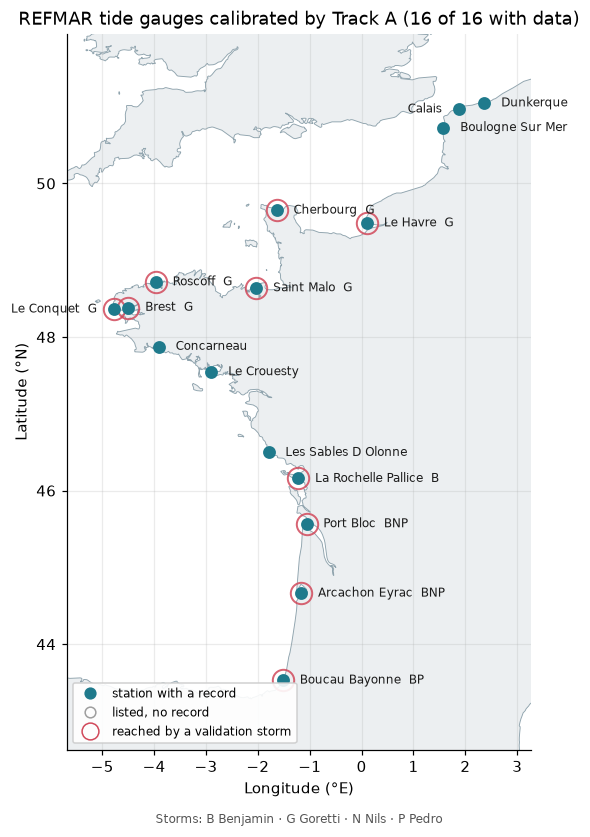

In [2]:
# Tide-gauge network on the French Atlantic and Channel coasts.
fh.plot_station_map()


### Interactive surge time-series explorer

The observed surge, the raw Tolosa-SW forecast and the corrected series are shown on the explorer below, at native 10-minute resolution.

1. **Select a station and a series** — Choose a tide gauge and toggle the observed surge, the raw Tolosa-SW forecast, and the corrected series.
2. **Explore the time series** — Drag to zoom into a storm event (double-click to reset).
3. **Analyse the selected window** — A statistics panel reports RMSE, MAE, bias and correlation for every visible series against the observed surge.


In [3]:
# Interactive surge time-series explorer (per station).
fh.plot_timeseries_explorer()


Series,N,RMSE (m),MAE (m),Bias (m),Corr


### Errors at each gauge, overall and on storm events

The figure below gathers the scores of the validation period, station by station along the coast. The first row separates the two regimes: RMSE raw against corrected, with the storm values overlaid — storm events are defined per station as a surge above the `q95_train` threshold — and the share of error the correction removes, overall and on storms alone. The rows below displays the bias, the mean absolute error, the standard deviation of each series next to the observed one and the correlation with the observed surge.

Over the whole record, the correction removes between 7 % of the RMSE at Roscoff and 68 % at Les Sables-d'Olonne, with a median of 19 % across the network. Restricted to storm events the median rises to 24 %, and the reduction exceeds its all-data value at 11 of the 13 stations scored, the exceptions being Boulogne-sur-Mer and Le Havre. The correction therefore removes *more* error when the surge is large, which is the behaviour the product requires.

Raw RMSE ranges from 5.7 cm at Le Conquet to 18.8 cm at Les Sables-d'Olonne; after correction every station falls between 4.9 and 7.6 cm. The gain is largest where the barotropic model is weakest — the Bay of Biscay stations, where the missing baroclinic and steric signal is strongest — and smallest in Brittany, where the raw error is already close to 6 cm and little remains to be removed.

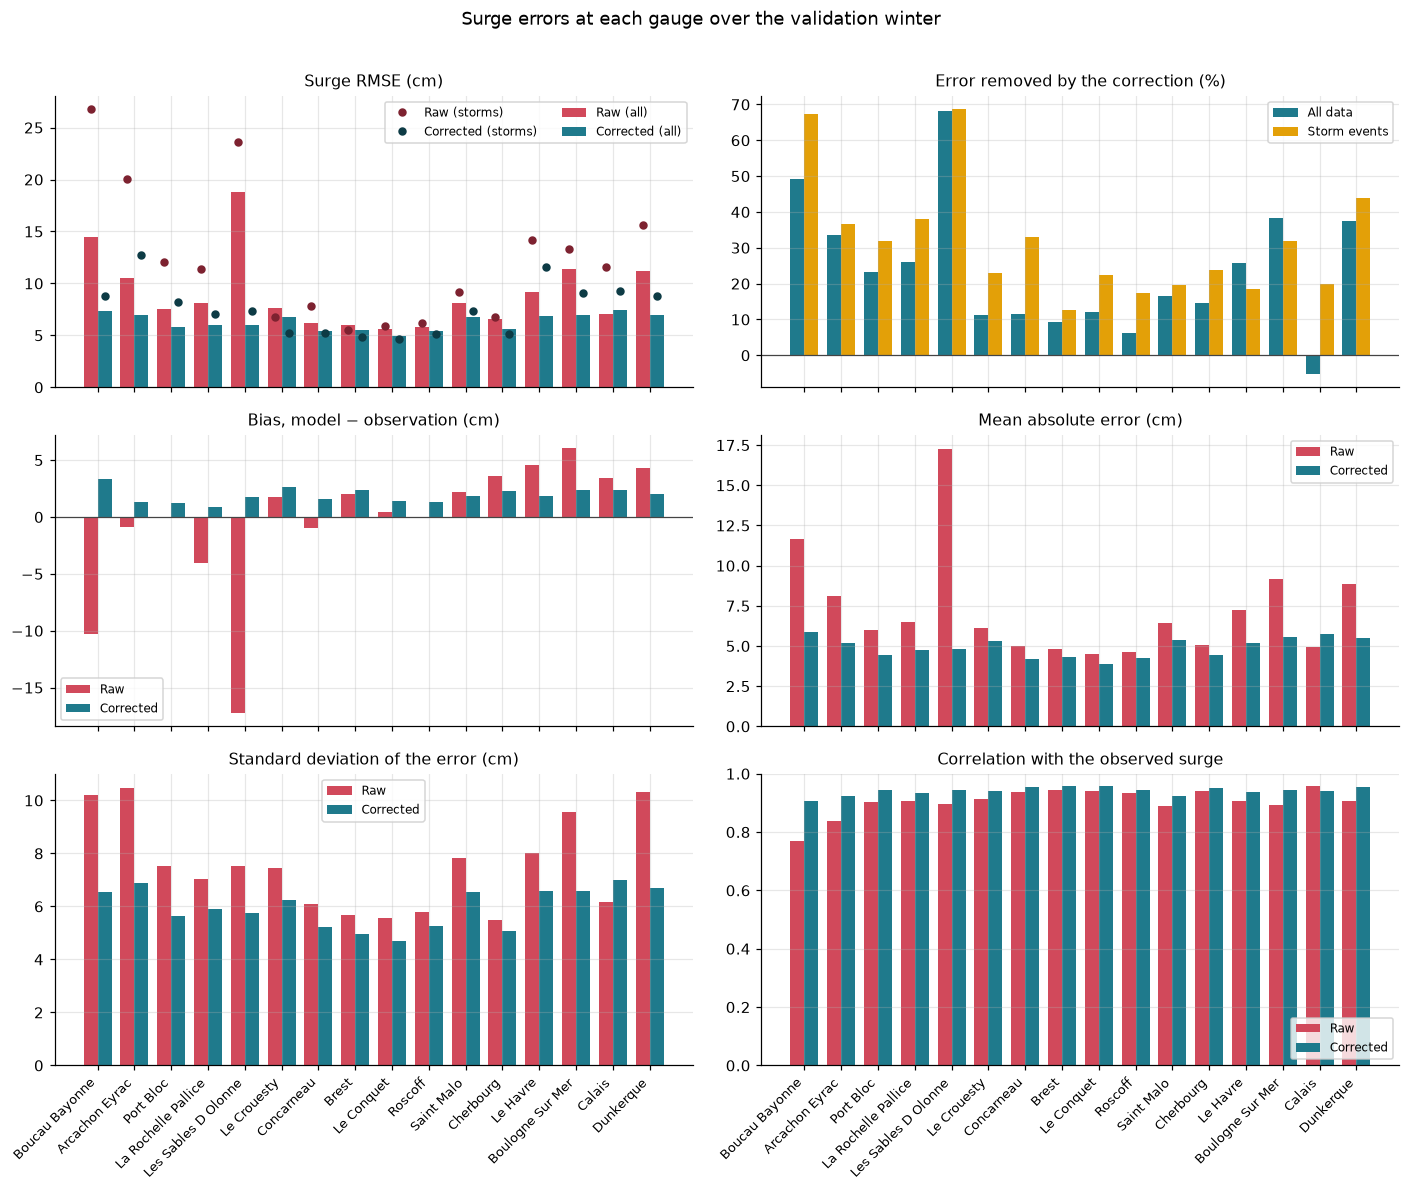

In [4]:
# Scores at each gauge: RMSE, error removed, bias and variability.
fh.plot_gauge_scores()

### Storm by storm, at the peak

The comparison is repeated event by event on the four named storms of the validation winter, over a ±24 h window centred on the **observed** surge peak at each station.

Three quantities are reported:

- the **RMSE over the window**;
- the **peak amplitude ratio**, the modelled maximum divided by the observed one;
- the **timing lag at the peak**, positive when the modelled peak arrives later.

The lag is estimated by cross-correlation over ±6 h. 

The window RMSE falls on all four storms: 4 % on Benjamin against 25 %, 32 % and 31 % on Goretti, Nils and Pedro. 

At the peak the correction improves the model on nearly all four storms. The mean ratio rises from 0.90 to 0.92, with the clearest gains on the two most under-predicted events, Pedro from 0.81 to 0.85 and Benjamin from 0.91 to 0.94. The same panel shows that on Nils and Pedro the corrected peak is still 14 to 15 % below the observed one — the amplitude of the largest surges stays under-predicted, although slightly improved.

Timing improves as well, the raw model peaks early at every storm, by 15 to 28 min. After correction the mean absolute lag falls from 23 to 18 min, and on Benjamin and Goretti the modelled peak is brought to within 2 and 14 min of the observed one. 

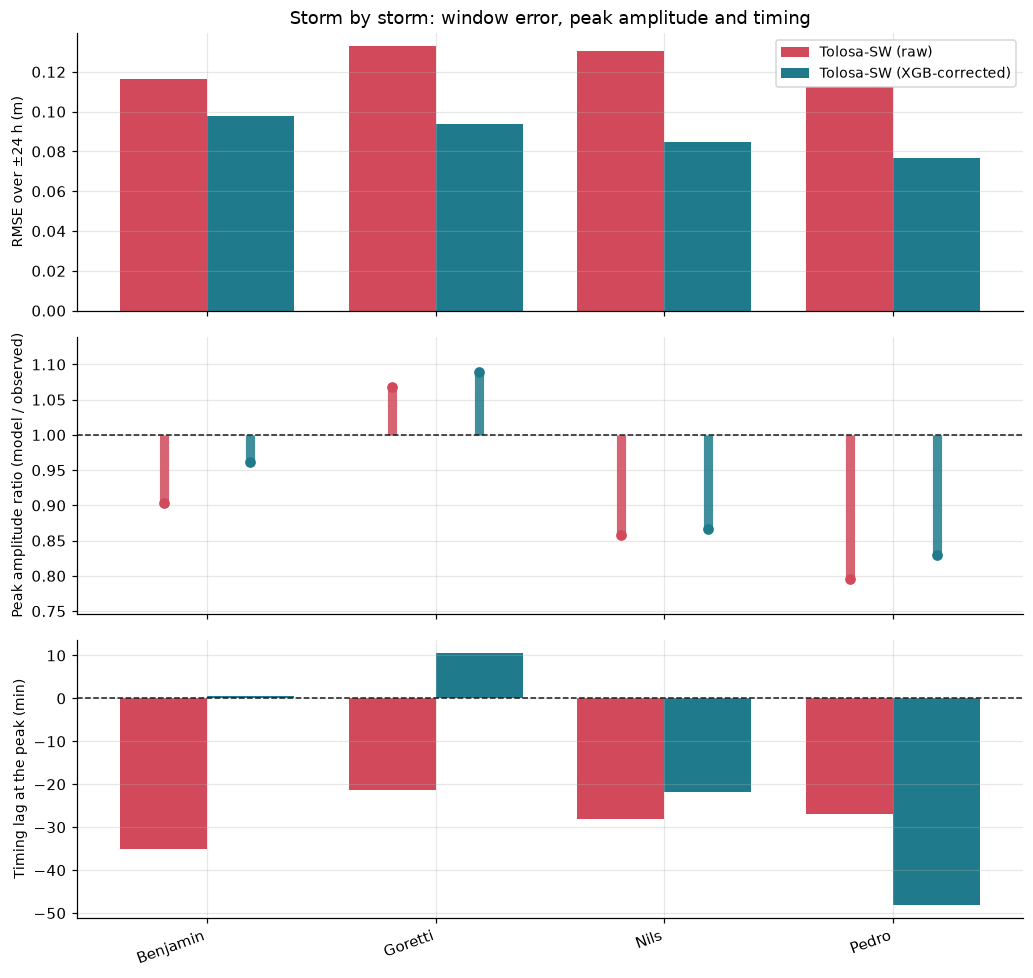

In [5]:
# Event-by-event scores around the observed surge peak.
events = fh.plot_event_scores()


### Extreme-event indicators (ECFAS)

The event-based indicators developed to assess the Copernicus Marine forecasts for the European Coastal Flood Awareness System (ECFAS; Irazoqui Apecechea et al., 2023) detects events jointly on the total water level and on the surge. The gauge records used here hold the surge, to which the method is applied:

- **extreme events** are detected objectively in the observed record, as peaks above the 99th percentile of the surge over the validation winter, separated by at least three days;
- the model **captures** an event when its own surge exceeds its 99th percentile within ± 24 h of the observed peak; a modelled event without an observed counterpart is a **false** event;
- on each detected event, the **peak error** (cm, and % of the observed peak) and the **timing error** are computed, the latter by cross-correlation as above.

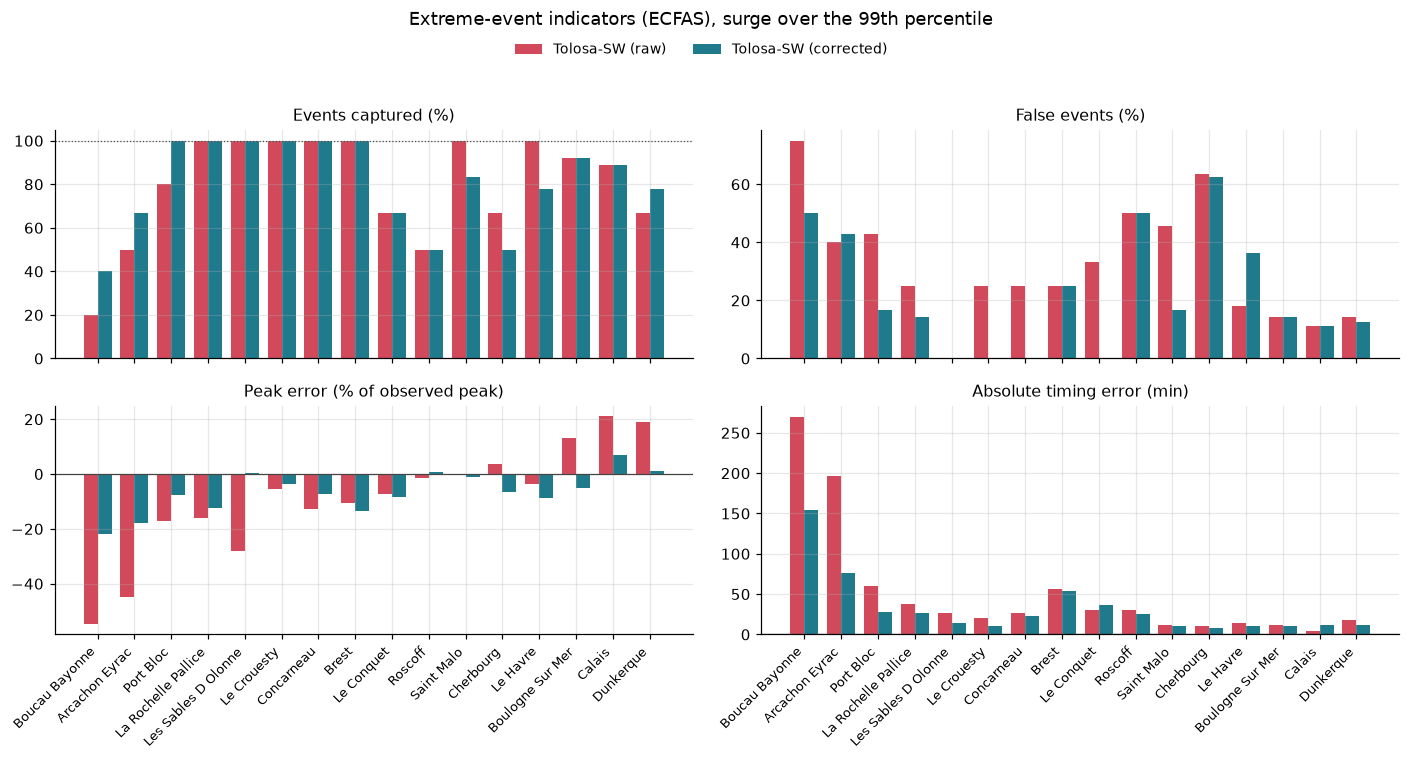

In [6]:
# ECFAS extreme-event indicators per gauge, raw against corrected.
# fh.ecfas_scores() returns the same indicators as a table.
fh.plot_ecfas_scores()

## Track B — Spatial bias correction from IBI

### Correction of the 2D surface field

The second approach corrects the **2D surface field**. Everything is compared in the *surge / de-tided* regime:

- **Tolosa-SW → surge**: tide removed (full − harmonic). Forced by pressure and wind, the model already holds its own atmospheric surge.
- **Satellite → SLA + DAC**: altimetry data are provided after the atmospheric response has been removed, in the form of a *dynamic atmospheric correction*. By reincorporating this correction, we obtain a reference that reflects atmospheric conditions similar to those in the model, so that the difference between the two corresponds to what is missing from the model.
- **IBI → de-tided `zos` − DAC**: the same correction is subtracted here, leaving a predictor with no atmospheric surge.

Removing the tide everywhere isolates the surge-driven, baroclinic part of the bias, which is the part IBI can inform. 

The reference bias is then defined by:

$$\text{bias\_ref}(t, y, x) = \big[\text{SLA}(t,y,x) + \text{DAC}(t,y,x)\big] - \text{Tolosa}_{\text{surge}}(t,y,x),$$

and estimated from the IBI predictor on a **single spectral band [20, 128] days** isolated by band-pass filtering.

### Record and evaluation period

The test period runs from **31 May 2025 to 16 January 2026**, 231 days at the daily resolution of the altimetry.

### Band edges

Both edges of the band are set by an explicit constraint.

- The **lower edge at 20 d**: filter the atmospheric surge, which the barotropic model already resolves.
- The **upper edge at 128 d**: set by what the record can validate. It is about half the 231-day test period, so every period retained completes at least one and a half cycles there, and about seven in the calibration window.


### The retained configuration

The correction models the relation `bias = f(IBI)` with a **regression in EOF space**, in the canonical-correlation form, on the band-pass-filtered **[20, 128] d** signal.

A comparison phase, not shown here, evaluated several other families on the same band, among them spatial analogues, point-by-point regression and fixed-radius Gaussian smoothing. The Copernicus Marine global analysis and forecast (GLO, `GLOBAL_ANALYSISFORECAST_PHY_001_024`) was also considered as a predictor and not retained, as it performed less well than IBI.

**Why a regression in EOF space.** At these periods the bias is large-scale and spatially smooth. Projecting both fields onto their leading empirical orthogonal functions compresses them into a handful of coherent patterns, and the regression is fitted between those coefficients. Dimensionality drops by three orders of magnitude, the retained patterns are physically readable, and the method proved the most skilful of the families tested on both 2D references. The method is described in the technical section at the end of the notebook.


### Interactive 2D map comparator

The widget below compares 2D outputs of different Tolosa-SW versions (raw or corrected) side by side. A date slider steps through the days of the test period, one at a time.


In [7]:
# Interactive 2D map comparator (de-tided / surge / SLA).
fh.build_map_cache()
fh.plot_map_comparator()


### Scores over the domain

The skill score is computed element by element over the whole test period, against the bias-climatology baseline:

$$SS = 1 - \frac{\mathrm{MSE}_{\text{corrected}}}{\mathrm{MSE}_{\text{baseline}}},$$

both mean squared errors being taken over the test period at the same element. Zero means the correction did no better than the baseline, one that it removed the error entirely, and a negative value that it degraded the field there.

The gain is spatially uniform across the domain, with the mean squared error reduced by half at best (averaged skill +0.310). Negative skill appears over a small part of the domaine (~3%).

The table below reports, over the same period, the error of the field before and after correction, cell by cell then averaged over the domain. 

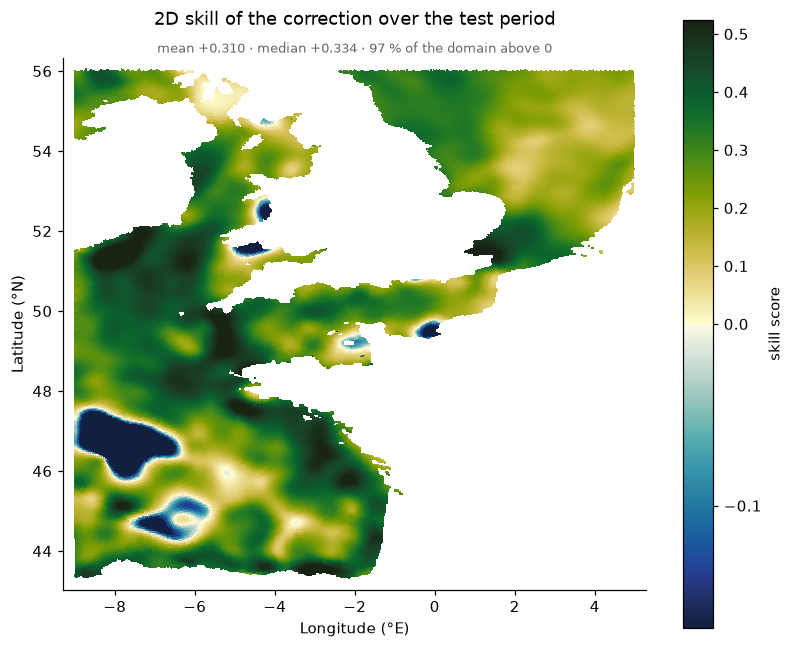

In [8]:
# Element-by-element 2D skill over the Track B test period.
fh.plot_skill_map()

In [9]:
# Error of the 2D field before and after correction, over the test period.
fh.field_scores_2d()

,RMSE (cm),MAE (cm),EV (bias variance removed),Skill
"117678 cells, 231 days",,,,
Tolosa-SW raw,5.300,4.333,0.000,0.00
Tolosa-SW corrected,4.639,3.681,0.198,0.31


### Scope and limits of the 2D correction

- **Waves.** The correction is learnt against altimetry, which does not resolve the wave-induced set-up at the coast, so wave effects on the sea surface height are outside its reach. 
- **Time scales.** The reference is a daily altimetric product, and the retained band keeps periods from 20 to 128 days: it holds a large-scale slowly varying field.
- **Domain.** The correction is defined where IBI overlaps the Tolosa-SW mesh — the Bay of Biscay, the Channel and the southern North Sea, up to 56° N and 5° E. 

---
# HOW? — How this application was made and improved within FOCCUS

Both corrections are **post-processing** layers: each correction is applied downstream on the product it targets. This keeps the operational model stable while injecting the physical processes it does not represent.

## The Tolosa-SW model

Tolosa-SW solves the non-linear shallow-water equations over variable bathymetry, with source terms for bottom dissipation, tidal forcing, atmospheric pressure and surface wind. It runs on an unstructured mesh with low-dissipation numerical schemes suited to non-linear flows in the low-Froude regime (Couderc et al., 2017). The mesh resolution ranges from about 100 m along the Channel and Atlantic coasts to 10–20 km in the northern part of the domain, near Norway, and was built from the bathymetric gradients under CFL constraints (Roberts et al., 2019).

The open boundaries are forced by water levels from the FES2014b tidal atlas, an improvement on FES2012 in resolution and in the assimilation of altimetry (Lyard et al., 2021). The other boundaries are vertical walls. Wind stress follows a Charnock relation with a constant Charnock parameter, and the effect of atmospheric pressure on the water level is represented by the inverse barometer.

## Modelling system integration

Inputs to the two tracks span the Copernicus Marine Service portfolio and national observation networks:

| Source | Role | Tide | Atm. surge | Steric (LF) |
|--------|------|:----:|:----------:|:-----------:|
| Tolosa-SW (`htot`) | model, total sea level | ✓ | ✓ | – |
| Tolosa-SW (`surge`) | model, de-tided target | – | ✓ | – |
| IBI (`zos`) | CMEMS 3D predictor | ✓ | ✓ | ✓ |
| DUACS SLA | altimetry reference (anomaly) | – | – | ✓ |
| Tide gauge (REFMAR) | in-situ reference | ✓ | ✓ | ✓ |
| Arpège (`u10`, `v10`, MSL) | atmospheric forcing | – | ✓ | – |
| WW3 (`Hs`, `Tm0`) | wave predictor | – | ✓ | – |
| FES2014b | tidal forcing at the Tolosa-SW open boundaries | ✓ | – | – |

Two of these products have been modified before use: the atmospheric surge is **restored** in the altimetric reference, and **removed** from the IBI predictor.


### Copernicus Marine products

| Role | Product ID | Dataset | DOI |
|------|------------|---------|-----|
| 3D predictor, 15-min instantaneous surface fields | `IBI_ANALYSISFORECAST_PHY_005_001` | `cmems_mod_ibi_phy_anfc_0.027deg-2D_PT15M-i` | [10.48670/moi-00027](https://doi.org/10.48670/moi-00027) |
| Altimetry reference, gridded SLA at 0.0625° | `SEALEVEL_EUR_PHY_L4_MY_008_068` | `cmems_obs-sl_eur_phy-ssh_my_allsat-l4-duacs-0.0625deg_P1D` | [10.48670/moi-00141](https://doi.org/10.48670/moi-00141) |

The application workflow — modelling-system integration within Copernicus Marine Services and FOCCUS developments, with links to the respective deliverables and milestones — is given in the schematic below.


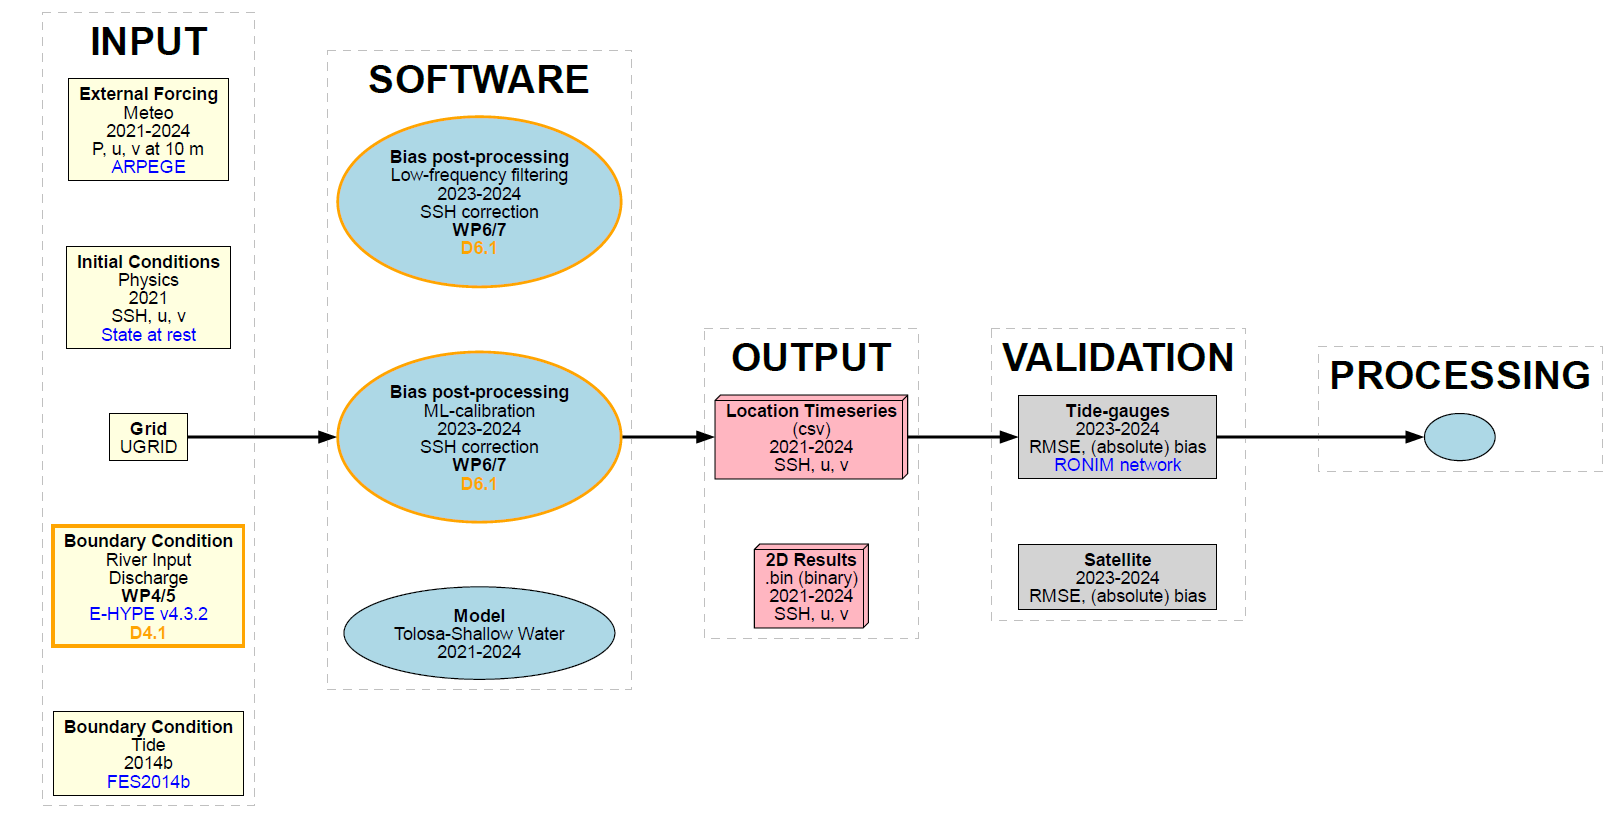

In [10]:
# Data-flow schematic
fh.plot_dataflow()


Within FOCCUS, the Tolosa-SW post-processing chain was developed in **WP6/7 (D6.1)**: the Tolosa-SW model system, interfaced with the Copernicus Marine IBI products, is complemented by a bias post-processing through low-frequency filtering and machine-learning calibration. The E-HYPE river discharges of **WP4/5** were considered as boundary conditions of Tolosa-SW and not retained, their effect on the surge being small.

## Technical work — summary

**Track A — XGBoost (1D, per port).** Inputs at native 10-min resolution are turned into physically-motivated predictors, then one model per station is trained.

<details>
<summary><b>Feature families and training strategy</b> (click to expand)</summary>

**What XGBoost does.** A supervised gradient-boosted regression that builds an ensemble of shallow decision trees, each new tree fitting the residual error of the ones before it. The relation between the surge error and its drivers (tide state, wind, waves, large-scale SSH) is strongly non-linear and full of interactions — exactly what a tree ensemble captures — while remaining fast to train and robust to irrelevant predictors. The algorithm follows the gradient-boosting framework of Friedman (2001) in the regularised, scalable form of Chen and Guestrin (2016).

**Feature engineering — five families:**

- **Temporal lags and derivatives** (`surge_mod`, wind, MSL at t−3/6/12 h, plus `dP/dt`, `d|wind|/dt`, `d surge_mod/dt`): surge has several hours of memory, and the derivatives separate a *growing* storm from a *relaxing* one — the model bias is asymmetric between the two regimes.
- **Tidal features** (`mas`, local tidal range over ±6 h, `d tide/dt`, and the cross term `tide × surge_mod`): barotropic models have a known tide–surge interaction error, strongest in the Channel and estuaries.
- **Wind decomposition into cross-shore / along-shore** components via each station's coastal-normal angle (`coast_normal_deg`): the surge response to wind is strongly direction-dependent, and the natural basis is relative to the coast, not to north.
- **Wave-setup proxy** `Hs² · cos(θ_wave − θ_coast)`: wave setup is largely absent from a barotropic model and is a sizeable part of the residual at exposed sites.
- **IBI complementarity** (surface SSH and currents) and **calendar encodings** (sin/cos of day-of-year and hour) for residual seasonal and diurnal regimes.

**Training strategy.**
- **Chronological training / validation split**, cut at 1 September so no winter is ever split across the two blocks.
- **Leave-one-winter-out cross-validation** inside the training block — each winter is held out in turn.
- **Continuous `sample_weight`** — a `quantile_boost` scheme (q = 0.95, α = 5.0), computed on `surge_obs` rather than on the error to avoid an auto-referential bias.

</details>

**Track B — IBI (2D, gridded).** All sources are projected onto the IBI grid through pre-computed sparse weight matrices; `bias_ref = (SLA + DAC) − Tolosa_surge` is formed in the de-tided anomaly regime, the atmospheric correction being added back to the altimetry and subtracted from the IBI predictor. The base method is calibrated on the single [20, 128] d band; a regression in EOF space is the configuration retained after a comparison phase not shown here. The resulting 2D correction is interpolated back to the Tolosa nodes.

<details>
<summary><b>More information — regression in EOF space</b> (click to expand)</summary>

Rather than fitting one relation per grid point, the method first compresses both fields. The band-passed IBI predictor and the reference bias are each projected onto their leading **empirical orthogonal functions** — the spatial patterns that carry most of their variance (Preisendorfer, 1988) — and the regression is fitted between the few resulting time coefficients. The pairs of patterns are chosen for the strength of their coupling, in the canonical-correlation framework used for seasonal forecasting since Barnett and Preisendorfer (1987).

</details>


---
## References

- Barnett, T. P., & Preisendorfer, R. (1987). Origins and levels of monthly and seasonal forecast skill for United States surface air temperatures determined by canonical correlation analysis. *Monthly Weather Review*, 115, 1825–1850.
- Chen, T., & Guestrin, C. (2016). XGBoost: a scalable tree boosting system. *Proceedings of KDD '16*, 785–794. [doi:10.1145/2939672.2939785](https://doi.org/10.1145/2939672.2939785)
- Couderc, F., Duran, A., & Vila, J.-P. (2017). An explicit asymptotic preserving low Froude scheme for the multilayer shallow water model with density stratification. *Journal of Computational Physics*, 343, 235–270.
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *The Annals of Statistics*, 29, 1189–1232.
- Irazoqui Apecechea, M., Melet, A., & Armaroli, C. (2023). Towards a pan-European coastal flood awareness system: skill of extreme sea-level forecasts from the Copernicus Marine Service. *Frontiers in Marine Science*, 9, 1091844. [doi:10.3389/fmars.2022.1091844](https://doi.org/10.3389/fmars.2022.1091844)
- Lyard, F. H., Allain, D. J., Cancet, M., Carrère, L., & Picot, N. (2021). FES2014 global ocean tide atlas: design and performance. *Ocean Science*, 17, 615–649. [doi:10.5194/os-17-615-2021](https://doi.org/10.5194/os-17-615-2021)
- Preisendorfer, R. W. (1988). *Principal Component Analysis in Meteorology and Oceanography*. Elsevier, Amsterdam.
- Roberts, K. J., Pringle, W. J., & Westerink, J. J. (2019). OceanMesh2D 1.0: MATLAB-based software for two-dimensional unstructured mesh generation in coastal ocean modeling. *Geoscientific Model Development*, 12, 1847–1868. [doi:10.5194/gmd-12-1847-2019](https://doi.org/10.5194/gmd-12-1847-2019)
